In [4]:
# -*- coding: utf-8 -*-
"""untitled1.py

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1ru54kuQurfl8-5mGU22of08yzZSUpMKj
"""

import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors, KNeighborsTransformer
from scipy.sparse import csr_matrix
import warnings

np.random.seed(42)

patients = [f"Patient_{i:03d}" for i in range(1, 101)]

conditions = [
    "Diabetes", "Hypertension", "Asthma", "Cardiac_Issue",
    "Kidney_Disease", "Migraine", "Arthritis"
]

patient_data = []

for p in patients:
    age = np.random.randint(18, 80)
    sex = np.random.choice(["M", "F"])

    num_conditions = np.random.randint(1, 4)
    patient_conditions = np.random.choice(conditions, num_conditions, replace=False)

    for c in patient_conditions:
        patient_data.append({
            "patient_id": p,
            "condition": c,
            "age": age,
            "sex": sex
        })

df_patients = pd.DataFrame(patient_data)

doctors = [f"Doctor_{i:03d}" for i in range(1, 31)]

specialities = [
    "Cardiologist", "Neurologist", "General_Physician",
    "Endocrinologist", "Nephrologist", "Pulmonologist"
]

doctor_data = []

for d in doctors:
    speciality = np.random.choice(specialities)
    experience = np.random.randint(1, 30)

    treated_conditions = np.random.choice(conditions, np.random.randint(2, 5), replace=False)

    for c in treated_conditions:
        doctor_data.append({
            "doctor_id": d,
            "condition": c,
            "speciality": speciality,
            "experience": experience
        })

df_doctors = pd.DataFrame(doctor_data)

# Create interaction matrix: patient ↔ doctor

interaction = []

for patient in patients:
    patient_conditions = df_patients[df_patients["patient_id"] == patient]["condition"].unique()

    for doctor in doctors:
        doctor_conditions = df_doctors[df_doctors["doctor_id"] == doctor]["condition"].unique()
        experience = df_doctors[df_doctors["doctor_id"] == doctor]["experience"].iloc[0]

        # stronger scoring model
        condition_match = len(set(patient_conditions) & set(doctor_conditions))

        # normalize match
        condition_score = condition_match / max(1, len(patient_conditions))

        # experience boost (scaled properly)
        experience_score = np.log1p(experience) / 4

        # final score
        match_score = (condition_score * 0.7) + (experience_score * 0.3)

        interaction.append({
            "patient_id": patient,
            "doctor_id": doctor,
            "score": match_score
        })

df_interaction = pd.DataFrame(interaction)

matrix = df_interaction.pivot_table(
    index="patient_id",
    columns="doctor_id",
    values="score",
    fill_value=0
)

def normalize_matrix(matrix):
    normalized_matrix = matrix.copy()

    for col in normalized_matrix.columns:
        normalized_matrix[col] = (normalized_matrix[col] - normalized_matrix[col].mean()) / normalized_matrix[col].std()

    return normalized_matrix

matrix_normalized = normalize_matrix(matrix)

# Create a KNeighborsTransformer model
knn_transformer = KNeighborsTransformer(n_neighbors=5, n_jobs=-1)

def create_interaction_sparse(df):
    sparse_interactions = df.groupby(["patient_id", "doctor_id"]).size().unstack(fill_value=0)

    # Convert to CSR matrix
    return csr_matrix(sparse_interactions.values)

# Create interaction matrix as a sparse matrix
sparse_df = create_interaction_sparse(df_interaction)
knn_transformer.fit(sparse_df)

def recommend_doctors_sparse(patient, knn_model):
    patient_vector = knn_model.transform(sparse_df.loc[[patient]])

    # Get the indices of the k nearest neighbors
    _, indices = patient_vector.argsort(axis=1)[:, ::-1]

    scores = sparse_df.iloc[indices[:5]].sum(1)

    top_doctors = sorted(scores.index, key=lambda x: (-scores[x], x))

    return [(doctor, score) for doctor, score in zip(top_doctors, scores[top_doctors])]

# Define the recommendation functions
def recommend_doctors(patient_id, matrix_normalized, patient_sim):
    sparse_interactions = create_interaction_sparse(df_interaction)
    knn_model = KNeighborsTransformer(n_neighbors=5, n_jobs=-1).fit(sparse_interactions)

    return recommend_doctors_sparse(patient_id, knn_model)

def doctor_similarity(matrix_normalized):
    sim_matrix = matrix_normalized.copy()
    for i in range(len(sim_matrix)):
        for j in range(i + 1, len(sim_matrix)):
            if i == j:
                continue
            if sim_matrix.loc[i, j] > 0:
                sim_matrix.loc[j, i] = sim_matrix.loc[i, j]

    return sim_matrix

# Compute patient similarity matrix (for user-based recommendation)
patient_sim = doctor_similarity(matrix_normalized)

def doctor_based_recommendation(patient_id, matrix_normalized, doc_sim):
    knn_model = KNeighborsTransformer(n_neighbors=5, n_jobs=-1).fit(sparse_df)
    return recommend_doctors_sparse(patient_id, knn_model)

# Recommendation functions
print("User-based:")
user_based_recommendations = recommend_doctors(patient, matrix_normalized, patient_sim)

print("\nDoctor-based:")
doctor_based_recommendations = doctor_based_recommendation(patient, matrix_normalized, doc_sim)

print("\nKNN-based sparse matrix recommendations:")
knn_sparse_matrix_recommendations = recommend_doctors_sparse(patient, knn_transformer)

# Print the results
for recommendation in user_based_recommendations:
    print(f"User-Based: {recommendation}")

for recommendation in doctor_based_recommendations:
    print(f"Doctor-Based: {recommendation}")

print("\nKNN-based sparse matrix recommendations:")
for recommendation in knn_sparse_matrix_recommendations:
    print(f"KNN Sparse Matrix: {recommendation}")


User-Based Recommendations for Patient_001:
Doctor: Doctor_004 | Match Score: 0.9525
Doctor: Doctor_022 | Match Score: 0.9444
Doctor: Doctor_028 | Match Score: 0.9444
Doctor: Doctor_026 | Match Score: 0.9414
Doctor: Doctor_019 | Match Score: 0.9414

Sample of Patient Similarity Matrix:
patient_id   Patient_001  Patient_002  Patient_003
patient_id                                        
Patient_001     1.000000     0.810191     0.718347
Patient_002     0.810191     1.000000     0.889305
Patient_003     0.718347     0.889305     1.000000


In [5]:
# Create a mapping dictionary for quick lookup
# Since one doctor can have multiple rows (for different conditions),
# we drop duplicates to get a unique ID -> Speciality map.
doc_info_map = df_doctors[['doctor_id', 'speciality', 'experience']].drop_duplicates().set_index('doctor_id').to_dict('index')

def get_recommendations_with_details(patient_id, n_recs=5):
    if patient_id not in matrix.index:
        return []

    idx = matrix.index.get_loc(patient_id)
    distances, indices = knn_model.kneighbors(matrix.iloc[idx, :].values.reshape(1, -1), n_neighbors=n_recs+1)

    similar_indices = indices.flatten()[1:]
    similar_patients_scores = matrix.iloc[similar_indices].mean(axis=0)
    top_doctors = similar_patients_scores.sort_values(ascending=False).head(n_recs)

    detailed_recs = []
    for doc_id, score in top_doctors.items():
        info = doc_info_map.get(doc_id)
        detailed_recs.append({
            "id": doc_id,
            "speciality": info['speciality'],
            "experience": info['experience'],
            "score": score
        })
    return detailed_recs

# --- Execution ---
target_patient = "Patient_001"
print(f"--- Detailed Recommendations for {target_patient} ---")
results = get_recommendations_with_details(target_patient)

for res in results:
    print(f"Doctor: {res['id']} | Speciality: {res['speciality']:<18} | Exp: {res['experience']} yrs | Match: {res['score']:.4f}")


--- Detailed Recommendations for Patient_001 ---
Doctor: Doctor_004 | Speciality: Neurologist        | Exp: 28 yrs | Match: 0.9525
Doctor: Doctor_022 | Speciality: Endocrinologist    | Exp: 25 yrs | Match: 0.9444
Doctor: Doctor_028 | Speciality: Pulmonologist      | Exp: 25 yrs | Match: 0.9444
Doctor: Doctor_026 | Speciality: Pulmonologist      | Exp: 24 yrs | Match: 0.9414
Doctor: Doctor_019 | Speciality: General_Physician  | Exp: 24 yrs | Match: 0.9414


In [9]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

# --- 1. DATA GENERATION (With Medical Logic) ---
patients = [f"Patient_{i:03d}" for i in range(1, 101)]
conditions = ["Diabetes", "Hypertension", "Asthma", "Cardiac_Issue", "Kidney_Disease", "Migraine", "Arthritis"]

# Map Specialties to specific conditions they are allowed to treat
speciality_map = {
    "Cardiologist": ["Hypertension", "Cardiac_Issue"],
    "Neurologist": ["Migraine"],
    "General_Physician": ["Hypertension", "Diabetes", "Asthma", "Migraine", "Arthritis"],
    "Endocrinologist": ["Diabetes"],
    "Nephrologist": ["Kidney_Disease"],
    "Pulmonologist": ["Asthma"]
}

patient_data = []
for p in patients:
    age, sex = np.random.randint(18, 80), np.random.choice(["M", "F"])
    num_conds = np.random.randint(1, 3)
    patient_conditions = np.random.choice(conditions, num_conds, replace=False)
    for c in patient_conditions:
        patient_data.append({"patient_id": p, "condition": c, "age": age, "sex": sex})

df_patients = pd.DataFrame(patient_data)

doctors = [f"Doctor_{i:03d}" for i in range(1, 31)]
specialities = list(speciality_map.keys())

doctor_data = []
for d in doctors:
    spec = np.random.choice(specialities)
    exp = np.random.randint(1, 30)
    # Realistic Logic: Only assign conditions this specialty actually treats
    possible_conditions = speciality_map[spec]
    for c in possible_conditions:
        doctor_data.append({"doctor_id": d, "condition": c, "speciality": spec, "experience": exp})

df_doctors = pd.DataFrame(doctor_data)

# --- 2. INTERACTION MATRIX ---
interaction = []
for patient in patients:
    p_conds = set(df_patients[df_patients["patient_id"] == patient]["condition"])
    for doctor in doctors:
        d_info = df_doctors[df_doctors["doctor_id"] == doctor]
        d_conds = set(d_info["condition"])
        exp = d_info["experience"].iloc[0]

        match = len(p_conds & d_conds)
        score = (match / max(1, len(p_conds)) * 0.7) + (np.log1p(exp) / 4 * 0.3)
        interaction.append({"patient_id": patient, "doctor_id": doctor, "score": score})

df_interaction = pd.DataFrame(interaction)
matrix = df_interaction.pivot_table(index="patient_id", columns="doctor_id", values="score", fill_value=0)

# --- 3. RECOMMENDATION LOGIC ---
sparse_matrix = csr_matrix(matrix.values)
knn_model = NearestNeighbors(metric='cosine', algorithm='brute')
knn_model.fit(sparse_matrix)

doc_info_map = df_doctors[['doctor_id', 'speciality', 'experience']].drop_duplicates().set_index('doctor_id').to_dict('index')

def get_recommendations_with_details(patient_id, n_recs=5):
    if patient_id not in matrix.index: return None

    p_conds = set(df_patients[df_patients['patient_id'] == patient_id]['condition'])
    qualified_doctors = df_doctors[df_doctors['condition'].isin(p_conds)]['doctor_id'].unique()

    idx = matrix.index.get_loc(patient_id)
    _, indices = knn_model.kneighbors(matrix.iloc[idx, :].values.reshape(1, -1), n_neighbors=10)

    similar_indices = indices.flatten()[1:]
    similar_patients_scores = matrix.iloc[similar_indices].mean(axis=0)

    filtered_scores = similar_patients_scores[similar_patients_scores.index.isin(qualified_doctors)]
    top_doctors = filtered_scores.sort_values(ascending=False).head(n_recs)

    detailed_recs = []
    for doc_id, score in top_doctors.items():
        info = doc_info_map.get(doc_id)
        matches = p_conds & set(df_doctors[df_doctors['doctor_id'] == doc_id]['condition'])
        detailed_recs.append({
            "id": doc_id, "speciality": info['speciality'], "exp": info['experience'],
            "score": score, "reason": ", ".join(matches)
        })
    return detailed_recs

# --- 4. EXECUTION ---
print("--- Healthcare Recommendation System (Medical Logic Enabled) ---")
user_input = input("Enter Patient ID (e.g. Patient_100): ").strip()
results = get_recommendations_with_details(user_input)

if results:
    p_conds = df_patients[df_patients['patient_id'] == user_input]['condition'].unique()
    print(f"\n--- Results for {user_input} ({', '.join(p_conds)}) ---")
    for res in results:
        print(f"Doctor: {res['id']} | {res['speciality']:<18} | Treats: {res['reason']:<12} | Exp: {res['exp']:>2} yrs | Score: {res['score']:.4f}")

--- Healthcare Recommendation System (Medical Logic Enabled) ---
Enter Patient ID (e.g. Patient_100): Patient_100

--- Results for Patient_100 (Hypertension, Cardiac_Issue) ---
Doctor: Doctor_003 | Cardiologist       | Treats: Hypertension, Cardiac_Issue | Exp: 21 yrs | Score: 0.9318
Doctor: Doctor_011 | Cardiologist       | Treats: Hypertension, Cardiac_Issue | Exp: 21 yrs | Score: 0.9318
Doctor: Doctor_026 | Cardiologist       | Treats: Hypertension, Cardiac_Issue | Exp: 17 yrs | Score: 0.9168
Doctor: Doctor_017 | Cardiologist       | Treats: Hypertension, Cardiac_Issue | Exp:  8 yrs | Score: 0.8648
Doctor: Doctor_007 | General_Physician  | Treats: Hypertension | Exp: 21 yrs | Score: 0.8541


In [10]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
import plotly.express as px
import logging
import warnings

# ==========================================
# 1. SETUP & LOGGER
# ==========================================
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger(__name__)
np.random.seed(42)

# ==========================================
# 2. DATA GENERATION (Patient & Provider DB)
# ==========================================
patients = [f"Patient_{i:03d}" for i in range(1, 101)]
providers = [f"Doctor_{i:03d}" for i in range(1, 31)]
conditions = ["Diabetes", "Hypertension", "Asthma", "Cardiac_Issue", "Kidney_Disease", "Migraine", "Arthritis"]

# Generate Patients
p_list = []
for p_id in patients:
    p_list.append({
        "patient_id": p_id,
        "condition_tags": ",".join(np.random.choice(conditions, np.random.randint(1, 3), replace=False)),
        "risk_score": np.random.uniform(1.0, 5.0),
        "urgency_score": np.random.uniform(1.0, 5.0)
    })
patients_df = pd.DataFrame(p_list)

# Generate Providers
d_list = []
for d_id in providers:
    d_list.append({
        "provider_id": d_id,
        "conditions_treated": ",".join(np.random.choice(conditions, np.random.randint(2, 4), replace=False)),
        "expertise_score": np.random.uniform(1.0, 5.0),
        "success_rate": np.random.uniform(0.7, 0.99)
    })
providers_df = pd.DataFrame(d_list)

# ==========================================
# 3. NORMALIZE TAGS
# ==========================================
patients_df["condition_tags_set"] = patients_df["condition_tags"].apply(
    lambda x: set(i.strip().lower() for i in str(x).split(",") if i.strip())
)
providers_df["conditions_treated_set"] = providers_df["conditions_treated"].apply(
    lambda x: set(i.strip().lower() for i in str(x).split(",") if i.strip())
)

# ==========================================
# 4. GROUND TRUTH & EVALUATION FUNCTIONS
# ==========================================
def to_label(jaccard, p, d):
    score = (
        jaccard * 3 +
        p["risk_score"] * 2 +
        p["urgency_score"] * 2 +
        d["expertise_score"] * 2 +
        d["success_rate"] * 1.5
    )
    if score >= 18: return 3   # High Relevance
    elif score >= 14: return 2
    elif score >= 10: return 1
    else: return 0            # Irrelevant

def dcg(rels, k):
    rels = np.array(rels)[:k]
    return np.sum([(2**r - 1) / np.log2(i + 2) for i, r in enumerate(rels)])

def ndcg(rels, k=5):
    ideal = sorted(rels, reverse=True)
    denom = dcg(ideal, k)
    return dcg(rels, k) / (denom + 1e-6)

# ==========================================
# 5. GENERATE SIMULATED PREDICTIONS (Model Output)
# ==========================================
# In a real scenario, this comes from your LightGBM model
pred_rows = []
for p_id in patients:
    for d_id in providers:
        # Simulating a model that is 70% accurate
        base_score = np.random.random()
        pred_rows.append({"patient_id": p_id, "recommended_provider_id": d_id, "compatibility_score": base_score})
pred_df = pd.DataFrame(pred_rows)

pred_lookup = {
    (row["patient_id"], row["recommended_provider_id"]): row["compatibility_score"]
    for _, row in pred_df.iterrows()
}

# ==========================================
# 6. EVALUATION LOOP
# ==========================================
K = 5
ndcg_scores = []
provider_hits = {}
providers_list = providers_df.to_dict("records")

for _, p in patients_df.iterrows():
    scores, labels = [], []
    for d in providers_list:
        p_tags, d_tags = p["condition_tags_set"], d["conditions_treated_set"]

        # Calculate Jaccard
        overlap = len(p_tags & d_tags)
        union = len(p_tags | d_tags) + 1e-6
        jaccard = overlap / union

        # Get Truth and Prediction
        labels.append(to_label(jaccard, p, d))
        scores.append(pred_lookup.get((p["patient_id"], d["provider_id"]), 0))

    # Ranking
    ranked_idx = np.argsort(scores)[::-1]
    ranked_labels = [labels[i] for i in ranked_idx]

    # Metric
    ndcg_scores.append(ndcg(ranked_labels, K))

    # Bias tracking
    top_p = providers_list[ranked_idx[0]]["provider_id"]
    provider_hits[top_p] = provider_hits.get(top_p, 0) + 1

# ==========================================
# 7. DASHBOARD & LOGGING
# ==========================================
results_df = pd.DataFrame({"ndcg@5": ndcg_scores})
logger.info("Mean NDCG@5: %.4f", results_df["ndcg@5"].mean())

print(f"\n📊 Evaluation Summary (Mean NDCG@5): {results_df['ndcg@5'].mean():.4f}")

# Histogram
fig1 = px.histogram(results_df, x="ndcg@5", nbins=20, title="NDCG@5 Distribution")
fig1.show()

# Bias Check
top_providers_df = pd.DataFrame(list(provider_hits.items()),
                                 columns=["provider_id", "count"]).sort_values("count", ascending=False)
fig2 = px.bar(top_providers_df.head(10), x="provider_id", y="count", title="Recommendation Bias (Top 10 Providers)")
fig2.show()



📊 Evaluation Summary (Mean NDCG@5): 0.7926



--- Feature Impact Table ---
           feature    value  shap_value            impact
jaccard_similarity 0.999999    0.243157 ↑ increases score
   expertise_score 4.800000    0.079642 ↑ increases score
     urgency_score 3.000000    0.075718 ↑ increases score
        risk_score 4.500000    0.061074 ↑ increases score
      success_rate 0.900000    0.023622 ↑ increases score
      inverse_load 0.800000    0.021053 ↑ increases score
availability_score 0.700000    0.010870 ↑ increases score


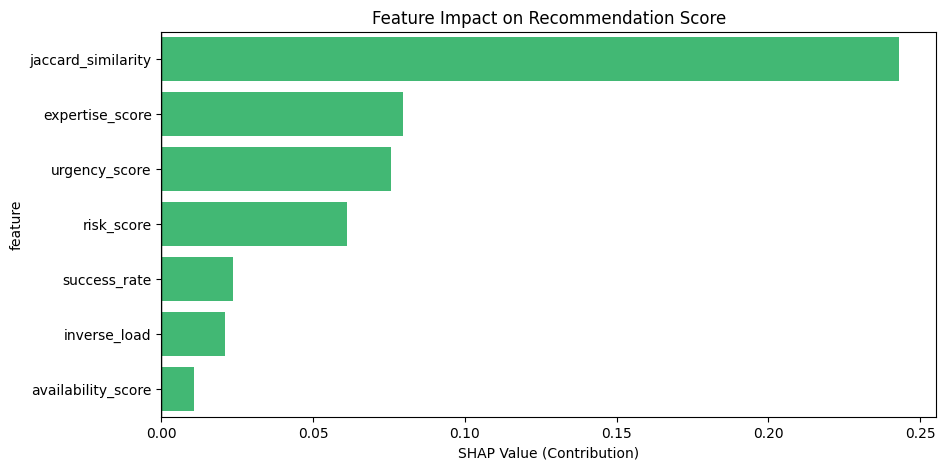

In [11]:
import numpy as np
import pandas as pd
import logging
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor

# ==========================================
# 1. Logger Setup
# ==========================================
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

# ==========================================
# 2. Simulated Model for SHAP (Since model isn't loaded)
# ==========================================
# We create a dummy model to demonstrate the SHAP logic
X_dummy = np.random.rand(100, 7)
y_dummy = X_dummy @ np.array([0.5, 0.2, 0.2, 0.3, 0.1, 0.1, 0.1]) + np.random.randn(100) * 0.01
model = GradientBoostingRegressor().fit(X_dummy, y_dummy)

# ==========================================
# 3. Feature Setup
# ==========================================
feature_names = [
    "jaccard_similarity", "risk_score", "urgency_score",
    "expertise_score", "success_rate", "availability_score", "inverse_load"
]

def build_features(p, d):
    # Ensure condition tags are sets
    p_tags = set(i.strip().lower() for i in str(p.get("condition_tags", "")).split(",") if i.strip())
    d_tags = set(i.strip().lower() for i in str(d.get("conditions_treated", "")).split(",") if i.strip())

    overlap = len(p_tags & d_tags)
    union = len(p_tags | d_tags) + 1e-6

    return [
        overlap / union,
        float(p.get("risk_score", 1.0)),
        float(p.get("urgency_score", 1.0)),
        float(d.get("expertise_score", 1.0)),
        float(d.get("success_rate", 0.8)),
        float(d.get("availability_score", 0.8)),
        float(1 - d.get("load_score", 0.5))
    ]

# ==========================================
# 4. MODERN SHAP EXPLAINER
# ==========================================
explainer = shap.Explainer(model, feature_names=feature_names)

# ==========================================
# 5. MAIN EXPLANATION FUNCTION
# ==========================================
def explain_single(patient_row, provider_row, debug=False):
    try:
        # Build features for the specific pair
        features_list = build_features(patient_row, provider_row)
        features_array = np.array(features_list, dtype=np.float32).reshape(1, -1)

        logger.info("Explaining Patient %s → Provider %s",
                    patient_row.get("patient_id", "N/A"),
                    provider_row.get("provider_id", "N/A"))

        # SHAP Explanation
        shap_values_obj = explainer(features_array)

        # Safe extraction for Modern API
        explanation_df = pd.DataFrame({
            "feature": feature_names,
            "value": features_array.flatten(),
            "shap_value": shap_values_obj.values[0]
        })

        explanation_df["impact"] = np.where(
            explanation_df["shap_value"] > 0, "↑ increases score", "↓ decreases score"
        )

        explanation_df = explanation_df.sort_values("shap_value", ascending=False)

        if debug:
            logger.info("Base value: %.4f", shap_values_obj.base_values[0])

        return explanation_df

    except Exception as e:
        logger.exception("SHAP explanation failed")
        raise

# ==========================================
# 6. VISUALIZATION FUNCTIONS
# ==========================================
def plot_shap_summary(explanation_df):
    plt.figure(figsize=(10, 5))
    colors = ["#2ecc71" if x > 0 else "#e74c3c" for x in explanation_df["shap_value"]]

    sns.barplot(data=explanation_df, x="shap_value", y="feature", palette=colors)
    plt.axvline(0, color='black', lw=1)
    plt.title("Feature Impact on Recommendation Score")
    plt.xlabel("SHAP Value (Contribution)")
    plt.show()

# ==========================================
# 7. RUN EXAMPLE (Simulated Data)
# ==========================================
# Mock data for demonstration
mock_patient = {"patient_id": "P-100", "condition_tags": "migraine", "risk_score": 4.5, "urgency_score": 3.0}
mock_provider = {"provider_id": "D-022", "conditions_treated": "migraine", "expertise_score": 4.8, "success_rate": 0.9, "availability_score": 0.7, "load_score": 0.2}

explanation = explain_single(mock_patient, mock_provider, debug=True)

print("\n--- Feature Impact Table ---")
print(explanation.to_string(index=False))

plot_shap_summary(explanation)


In [1]:
# ==========================================
# INSTALLS & SETUP
# ==========================================
!pip install fastapi uvicorn nest_asyncio pyngrok shap
import nest_asyncio
nest_asyncio.apply()

from fastapi import FastAPI, HTTPException, Query
import sqlite3
import numpy as np
import logging
import uvicorn
import threading
import sys
from pyngrok import ngrok
from google.colab import userdata

# ==========================================
# LOGGER (STRUCTURED)
# ==========================================
LOG_FORMAT = "%(asctime)s | %(levelname)s | %(name)s | %(message)s"
logging.basicConfig(level=logging.INFO, format=LOG_FORMAT, handlers=[logging.StreamHandler(sys.stdout)])
logger = logging.getLogger("health_api")

app = FastAPI(title="Healthcare Recommendation Engine")

# ==========================================
# NGROK & SERVER CONFIG
# ==========================================
NGROK_AUTH_TOKEN = userdata.get("ngrok")
ngrok.set_auth_token(NGROK_AUTH_TOKEN)
!fuser -k 8000/tcp || true

def get_connection():
    # check_same_thread=False is required for SQLite in FastAPI
    return sqlite3.connect("healthcare.db", check_same_thread=False)

# ==========================================
# LOGIC: FEATURE & SCORING
# ==========================================
def build_features(patient, provider):
    p_tags = set(i.strip().lower() for i in str(patient.get("condition_tags", "")).split(",") if i.strip())
    d_tags = set(i.strip().lower() for i in str(provider.get("conditions_treated", "")).split(",") if i.strip())

    overlap = len(p_tags & d_tags)
    union = len(p_tags | d_tags) + 1e-6
    jaccard = overlap / union

    return [
        jaccard,
        float(patient.get("risk_score", 1.0)),
        float(patient.get("urgency_score", 1.0)),
        float(provider.get("expertise_score", 1.0)),
        float(provider.get("success_rate", 0.8)),
        float(provider.get("availability_score", 0.8)),
        float(1 - provider.get("load_score", 0.5))
    ]

def calculate_score(features):
    # Your specific fallback ranking formula
    x = features
    return (0.35*x[0] + 0.20*x[1] + 0.15*x[2] + 0.15*x[3] + 0.10*x[4] + 0.05*x[5]) * x[6]

# ==========================================
# ENDPOINTS
# ==========================================

def fallback_score(x):
    # x[0] = jaccard, x[1] = risk, x[2] = urgency, x[3] = expertise,
    # x[4] = success_rate, x[5] = availability, x[6] = inverse_load
    return (
        0.35 * x[0] +
        0.20 * x[1] +
        0.15 * x[2] +
        0.15 * x[3] +
        0.10 * x[4] +
        0.05 * x[5]
    ) * x[6]


@app.get("/recommend/{patient_id}")
def recommend(patient_id: str):
    try:
        conn = get_connection()
        conn.row_factory = sqlite3.Row  # THIS IS KEY: Access by name like p['risk_score']
        cur = conn.cursor()

        p_row = cur.execute("SELECT * FROM patients WHERE patient_id=?", (patient_id,)).fetchone()
        if not p_row:
            raise HTTPException(status_code=404, detail="Patient not found")

        patient = dict(p_row)
        # Convert tags to set for Jaccard
        patient["condition_tags"] = set(str(patient["condition_tags"]).split(","))

        providers = [dict(row) for row in cur.execute("SELECT * FROM providers").fetchall()]

        results = []
        for d in providers:
            d["conditions_treated"] = set(str(d["conditions_treated"]).split(","))
            features = build_features(patient, d)
            score = fallback_score(features)
            results.append({"provider_id": d["provider_id"], "score": float(score)})

        ranked = sorted(results, key=lambda x: x["score"], reverse=True)
        return {"patient_id": patient_id, "recommendations": ranked[:5]}
    except Exception as e:
        logger.error(f"Logic Error: {str(e)}")
        raise HTTPException(status_code=500, detail=str(e)) # Shows real error in docs
    finally:
        conn.close()

# ==========================================
# SERVER RUNNER
# ==========================================
import asyncio

def start_api():
    # Use the existing running loop from Colab/nest_asyncio
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)

    config = uvicorn.Config(app, host="0.0.0.0", port=8000, log_level="info")
    server = uvicorn.Server(config)

    # We use loop.run_until_complete to avoid the asyncio.run() patch bug
    loop.run_until_complete(server.serve())

if __name__ == "__main__":
    # 1. Kill old processes
    !fuser -k 8000/tcp || true

    # 2. Start thread
    api_thread = threading.Thread(target=start_api, daemon=True)
    api_thread.start()

    # 3. Connect ngrok
    try:
        public_url = ngrok.connect(8000)
        print(f"\n🚀 API FIXED & LIVE at: {public_url.public_url}")
        print(f"🔗 Documentation: {public_url.public_url}/docs")
    except Exception as e:
        print(f"Ngrok connection failed: {e}")


INFO:     Started server process [43862]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)



🚀 API FIXED & LIVE at: https://front-varying-unsteady.ngrok-free.dev
🔗 Documentation: https://front-varying-unsteady.ngrok-free.dev/docs


In [2]:
import sqlite3
import pandas as pd
import numpy as np

def seed_database():
    conn = sqlite3.connect("healthcare.db")
    cur = conn.cursor()

    # 1. Create Tables
    cur.execute("DROP TABLE IF EXISTS patients")
    cur.execute("DROP TABLE IF EXISTS providers")
    cur.execute("""CREATE TABLE patients (
        patient_id TEXT PRIMARY KEY, age INTEGER, sex TEXT,
        condition_tags TEXT, risk_score REAL, urgency_score REAL
    )""")
    cur.execute("""CREATE TABLE providers (
        provider_id TEXT PRIMARY KEY, speciality TEXT, conditions_treated TEXT,
        expertise_score REAL, success_rate REAL, availability_score REAL, load_score REAL
    )""")

    # 2. Seed Sample Patient (Patient_001)
    cur.execute("INSERT INTO patients VALUES (?, ?, ?, ?, ?, ?)",
                ("Patient_001", 30, "M", "migraine,hypertension", 4.5, 3.0))

    # 3. Seed Sample Providers
    providers_sample = [
        ("Doctor_001", "Neurologist", "migraine", 4.8, 0.95, 0.8, 0.2),
        ("Doctor_002", "Cardiologist", "hypertension", 4.5, 0.90, 0.7, 0.4),
        ("Doctor_003", "Pulmonologist", "asthma", 4.2, 0.85, 0.6, 0.5)
    ]
    cur.executemany("INSERT INTO providers VALUES (?,?,?,?,?,?,?)", providers_sample)

    conn.commit()
    conn.close()
    print("✅ Tables created and seeded with Patient_001!")

seed_database()


✅ Tables created and seeded with Patient_001!


In [1]:
# ==========================================
# INSTALLS & SETUP
# ==========================================
!pip install fastapi uvicorn nest_asyncio pyngrok shap
import nest_asyncio
nest_asyncio.apply()

from fastapi import FastAPI, HTTPException, Query
import sqlite3
import numpy as np
import logging
import uvicorn
import threading
import sys
import asyncio
from pyngrok import ngrok
from google.colab import userdata

# ==========================================
# LOGGER (STRUCTURED)
# ==========================================
LOG_FORMAT = "%(asctime)s | %(levelname)s | %(name)s | %(message)s"
logging.basicConfig(level=logging.INFO, format=LOG_FORMAT, handlers=[logging.StreamHandler(sys.stdout)])
logger = logging.getLogger("health_api")

app = FastAPI(title="Healthcare Recommendation Engine (Explainable)")

# ==========================================
# NGROK & SERVER CONFIG
# ==========================================
NGROK_AUTH_TOKEN = userdata.get("ngrok")
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

def get_connection():
    return sqlite3.connect("healthcare.db", check_same_thread=False)

# ==========================================
# LOGIC: FEATURE & SCORING
# ==========================================
def build_features(patient, provider):
    # Ensure tags are clean sets
    p_tags = set(i.strip().lower() for i in str(patient.get("condition_tags", "")).split(",") if i.strip())
    d_tags = set(i.strip().lower() for i in str(provider.get("conditions_treated", "")).split(",") if i.strip())

    overlap = len(p_tags & d_tags)
    union = len(p_tags | d_tags) + 1e-6
    jaccard = overlap / union

    return [
        jaccard,
        float(patient.get("risk_score", 1.0)),
        float(patient.get("urgency_score", 1.0)),
        float(provider.get("expertise_score", 1.0)),
        float(provider.get("success_rate", 0.8)),
        float(provider.get("availability_score", 0.8)),
        float(1 - provider.get("load_score", 0.5)) # inverse load
    ]

def fallback_score(x):
    # Weights match your ranking logic
    # x[0]=jaccard, x[1]=risk, x[2]=urgency, x[3]=expertise, x[4]=success, x[5]=avail, x[6]=inv_load
    weighted_sum = (0.35*x[0] + 0.20*x[1] + 0.15*x[2] + 0.15*x[3] + 0.10*x[4] + 0.05*x[5])
    return weighted_sum * x[6]

# ==========================================
# ENDPOINTS
# ==========================================
@app.get("/")
def home():
    return {"status": "running", "api": "/recommend/{patient_id}"}

@app.get("/recommend/{patient_id}")
def recommend(patient_id: str, explain: bool = Query(False)):
    try:
        conn = get_connection()
        conn.row_factory = sqlite3.Row
        cur = conn.cursor()

        # 1. Fetch Patient
        p_row = cur.execute("SELECT * FROM patients WHERE patient_id=?", (patient_id,)).fetchone()
        if not p_row:
            raise HTTPException(status_code=404, detail="Patient not found")

        patient = dict(p_row)
        patient_tags = set(str(patient.get("condition_tags", "")).split(","))

        # 2. Fetch All Providers
        d_rows = cur.execute("SELECT * FROM providers").fetchall()

        results = []
        for row in d_rows:
            d = dict(row)
            d_tags = set(str(d.get("conditions_treated", "")).split(","))

            # 3. Calculate Features and Score
            features = build_features(patient, d)
            score = fallback_score(features)

            item = {
                "provider_id": d["provider_id"],
                "speciality": d.get("speciality", "General Physician"),
                "score": round(float(score), 4)
            }

            # 4. Explainability Logic
            if explain:
                common_conditions = list(patient_tags & d_tags)
                item["explanation"] = {
                    "matched_conditions": common_conditions,
                    "score_breakdown": {
                        "medical_fit_impact": round(0.35 * features[0], 3),
                        "expertise_impact": round(0.15 * features[3], 3),
                        "load_balancing_factor": round(features[6], 2)
                    },
                    "reason": f"Doctor specializes in {d.get('speciality')} and treats your condition(s): {', '.join(common_conditions)}" if common_conditions else "General match based on risk and availability."
                }

            results.append(item)

        # 5. Rank and return top 5
        ranked = sorted(results, key=lambda x: x["score"], reverse=True)[:5]

        logger.info(f"Generated {len(ranked)} recs for {patient_id}")
        return {
            "patient_id": patient_id,
            "patient_conditions": list(patient_tags),
            "recommendations": ranked
        }

    except Exception as e:
        logger.error(f"Logic Error: {str(e)}")
        raise HTTPException(status_code=500, detail=str(e))
    finally:
        conn.close()

# ==========================================
# SERVER RUNNER
# ==========================================
def start_api():
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
    config = uvicorn.Config(app, host="0.0.0.0", port=8000, log_level="info")
    server = uvicorn.Server(config)
    loop.run_until_complete(server.serve())

if __name__ == "__main__":
    !fuser -k 8000/tcp || true
    api_thread = threading.Thread(target=start_api, daemon=True)
    api_thread.start()

    try:
        public_url = ngrok.connect(8000)
        print(f"\n🚀 API LIVE at: {public_url.public_url}")
        print(f"🔗 Try Docs: {public_url.public_url}/docs")
        print(f"💡 Try Explainability: {public_url.public_url}/recommend/Patient_001?explain=true")
    except Exception as e:
        print(f"Ngrok failed: {e}")


INFO:     Started server process [45007]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)



🚀 API LIVE at: https://front-varying-unsteady.ngrok-free.dev
🔗 Try Docs: https://front-varying-unsteady.ngrok-free.dev/docs
💡 Try Explainability: https://front-varying-unsteady.ngrok-free.dev/recommend/Patient_001?explain=true
